In [4]:
import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_csv('/content/cleaned_dataset.csv', low_memory=False)

# 2. Clean column names (handles both single-level and MultiIndex columns)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(map(str, col)).strip().lower() for col in df.columns]
else:
    df.columns = df.columns.astype(str).str.strip().str.lower()

# 3. Remove duplicates
df.drop_duplicates(inplace=True)

# 4 & 5. Fill Missing Values safely
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Vectorized fill
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna('unknown')

# 6. Verify shape
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print("Cleaned shape:", df.shape)

Remaining missing values: 0
Cleaned shape: (36033, 48)


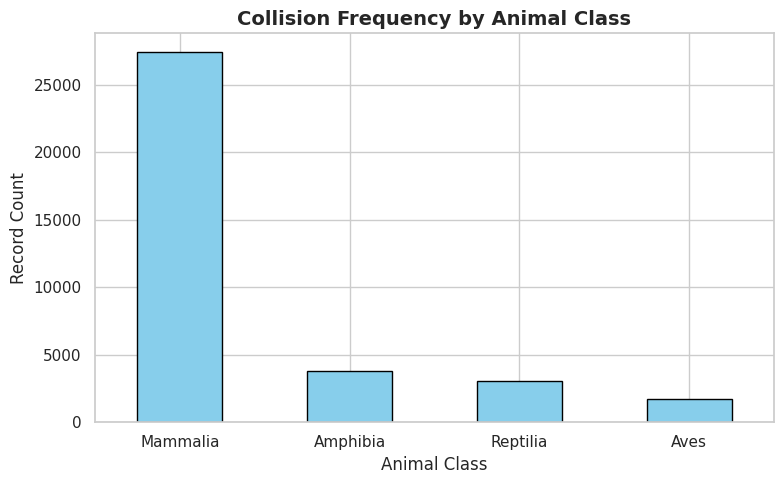

/tmp/ipykernel_1705/2311256591.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_species.values, y=top_species.index, palette='viridis')


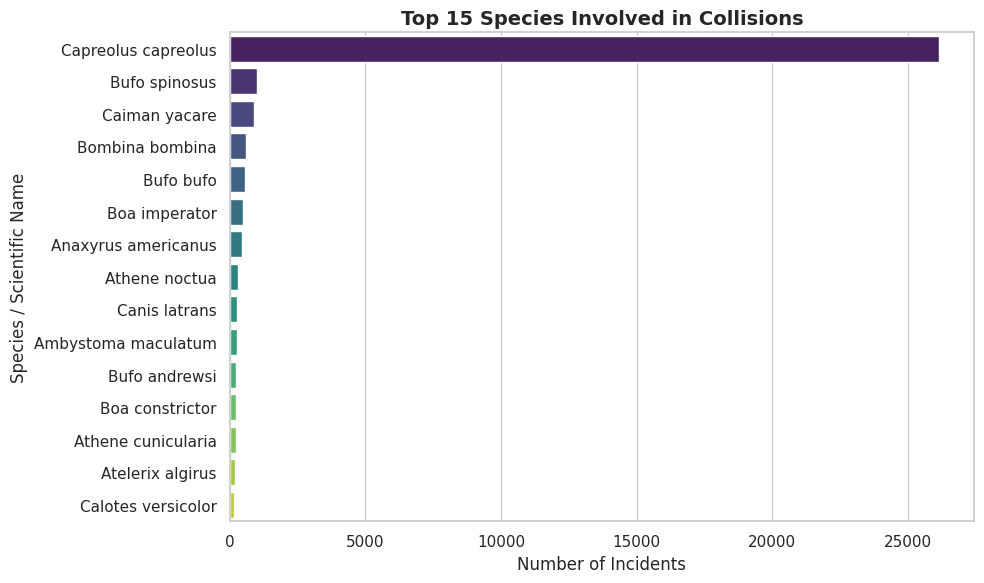

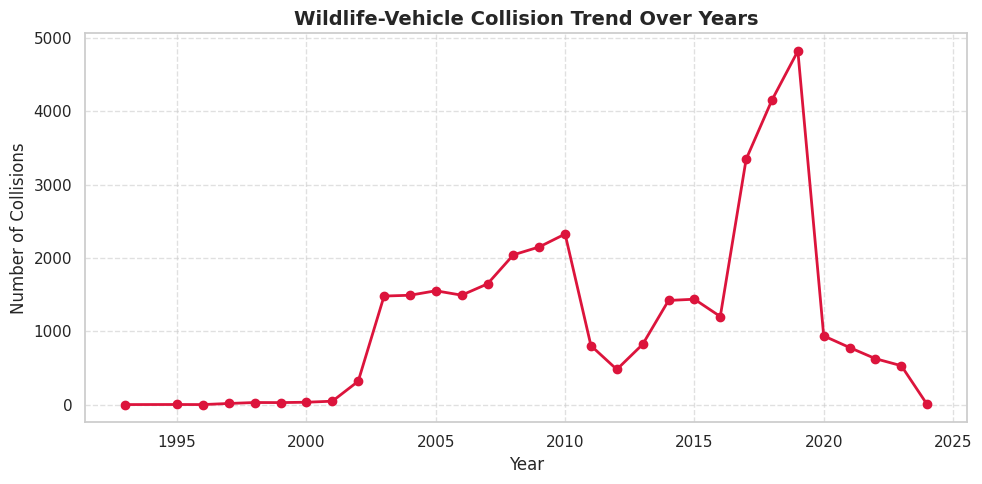

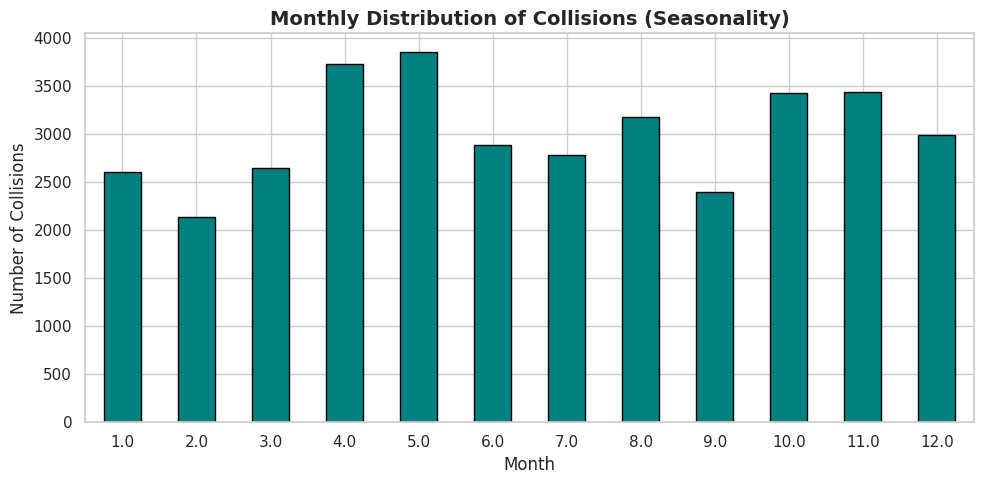

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. SPECIES & BIODIVERSITY ANALYSIS

#  Animal Class Distribution
class_col = next((col for col in df.columns if 'class' in col.lower()), None)

if class_col:
    plt.figure(figsize=(8, 5))
    df[class_col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title("Collision Frequency by Animal Class", fontsize=14, fontweight='bold')
    plt.xlabel("Animal Class", fontsize=12)
    plt.ylabel("Record Count", fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#  Top 15 Species Involved
species_col = next((col for col in df.columns if any(x in col.lower() for x in ['scientificname', 'species', 'commonname'])), None)

if species_col:
    plt.figure(figsize=(10, 6))
    top_species = df[species_col].value_counts().head(15)
    sns.barplot(x=top_species.values, y=top_species.index, palette='viridis')
    plt.title("Top 15 Species Involved in Collisions", fontsize=14, fontweight='bold')
    plt.xlabel("Number of Incidents", fontsize=12)
    plt.ylabel("Species / Scientific Name", fontsize=12)
    plt.tight_layout()
    plt.show()



# 2. TEMPORAL ANALYSIS

#  Yearly Trend
if 'year' in df.columns:
    plt.figure(figsize=(10, 5))
    df['year'].value_counts().sort_index().plot(kind='line', marker='o', color='crimson', linewidth=2)
    plt.title("Wildlife-Vehicle Collision Trend Over Years", fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of Collisions", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

#  Monthly Distribution
if 'month' in df.columns:
    plt.figure(figsize=(10, 5))
    df['month'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black')
    plt.title("Monthly Distribution of Collisions (Seasonality)", fontsize=14, fontweight='bold')
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Number of Collisions", fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#  Hourly Distribution (Only runs if an hour/time column exists)
hour_col = next((col for col in df.columns if 'hour' in col.lower()), None)
if hour_col:
    plt.figure(figsize=(10, 5))
    df[hour_col].value_counts().sort_index().plot(kind='bar', color='purple', edgecolor='black')
    plt.title("Collisions by Hour of Day", fontsize=14, fontweight='bold')
    plt.xlabel("Hour (24-Hour Clock)", fontsize=12)
    plt.ylabel("Number of Collisions", fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

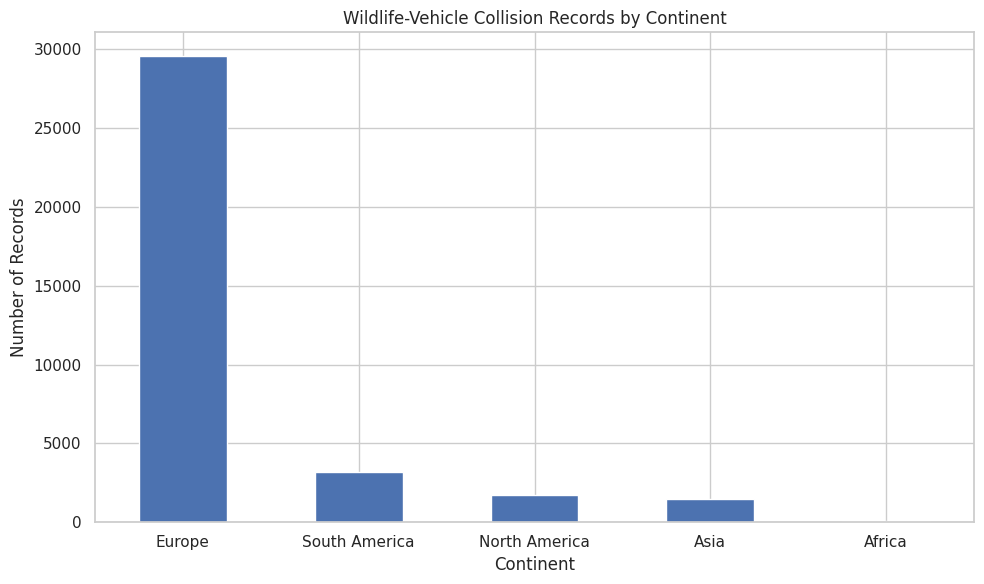

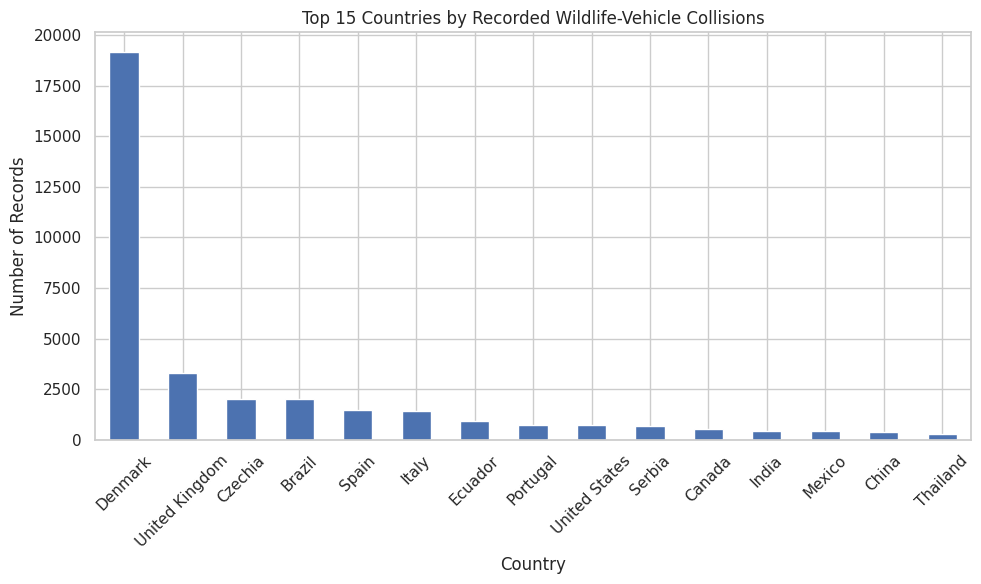

In [6]:
# Analysis 2 — Where are collisions recorded?
import matplotlib.pyplot as plt

# for cotinents.
df['continent'].value_counts()
continent_counts = df['continent'].value_counts()
continent_counts.plot(kind='bar', figsize=(10,6))

plt.title("Wildlife-Vehicle Collision Records by Continent")
plt.xlabel("Continent")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# for countries.
df['country'].value_counts().head(15)
country_counts = df['country'].value_counts().head(15)

country_counts.plot(kind='bar', figsize=(10,6))

plt.title("Top 15 Countries by Recorded Wildlife-Vehicle Collisions")
plt.xlabel("Country")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

class
Mammalia    27432
Amphibia     3812
Reptilia     3065
Aves         1724
Name: count, dtype: int64


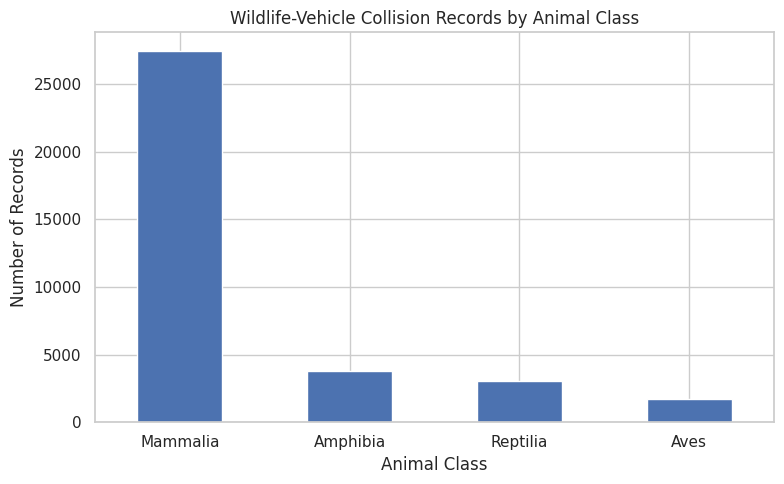

scientificname
Capreolus capreolus    26166
Bufo spinosus           1003
Caiman yacare            876
Bombina bombina          591
Bufo bufo                549
Boa imperator            471
Anaxyrus americanus      451
Athene noctua            297
Canis latrans            268
Bufo gargarizans         256
Ambystoma maculatum      253
Boa constrictor          241
Athene cunicularia       234
Atelerix algirus         194
Calotes versicolor       152
Name: count, dtype: int64


In [7]:
# Analysis 3- Which types of wildlife are most affected?
[col for col in df.columns if 'class' in col.lower()]
class_counts = df['class'].value_counts()
print(class_counts)
plt.figure(figsize=(8, 5))

class_counts.plot(kind='bar')

plt.title("Wildlife-Vehicle Collision Records by Animal Class")
plt.xlabel("Animal Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

species_counts = df['scientificname'].value_counts()
print(species_counts.head(15))


ROAD TYPE DISTRIBUTION
roadtype
paved (2 lanes)     18486
paved (1 lane)      12060
unknown              3114
paved (>2 lanes)     2255
unpaved               118
Name: count, dtype: int64


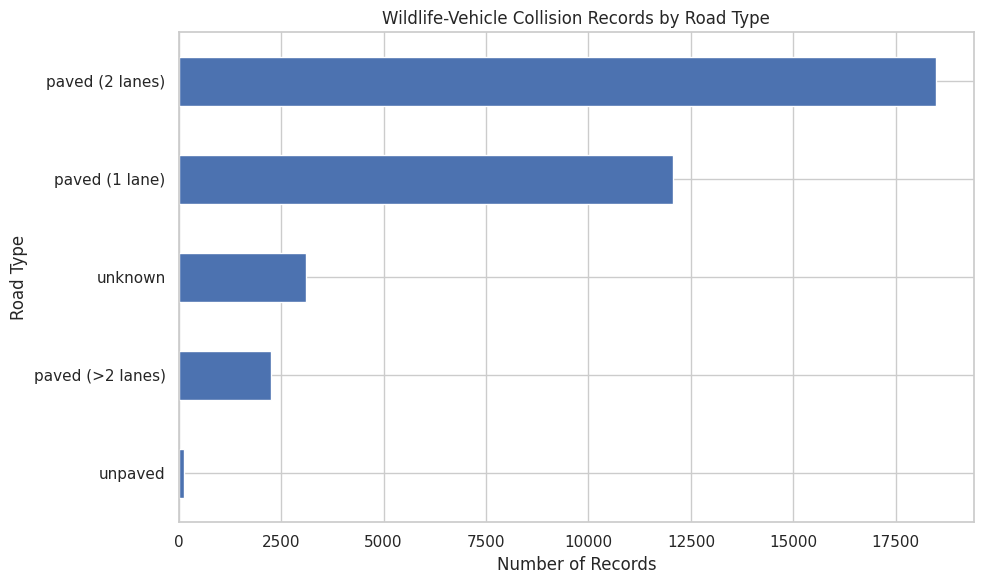


ERROR: Road Surface column not found.

ROAD LENGTH STATISTICS
count    36033.000000
mean        49.702559
std         91.995764
min          0.100000
25%         30.000000
50%         30.000000
75%         30.000000
max        855.000000
Name: roadlength, dtype: float64


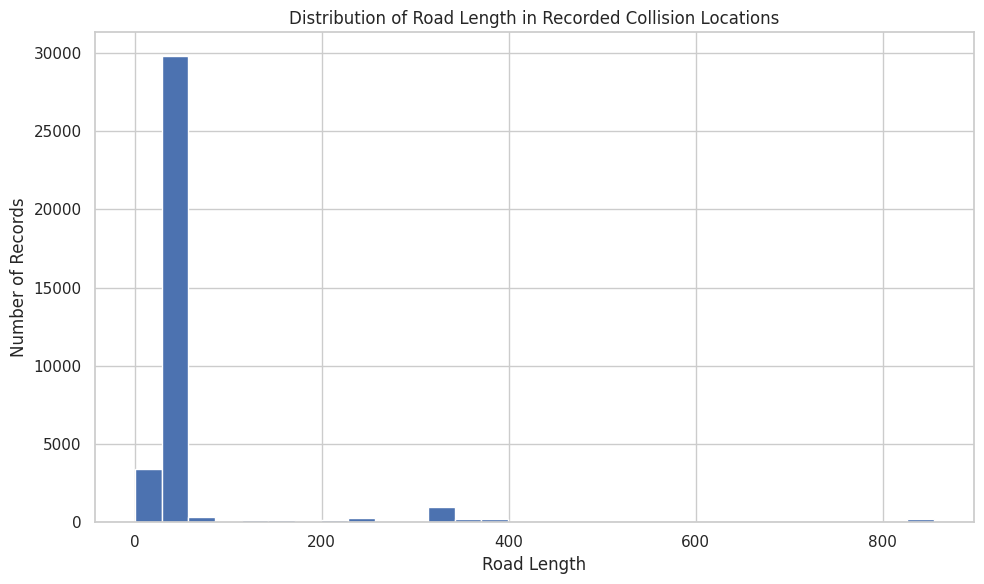


ERROR: Road Width column not found.


In [8]:
# ANALYSIS 4 — ROAD / INFRASTRUCTURE FACTORS
import pandas as pd
import matplotlib.pyplot as plt

# Find the road type column
road_type_col = next(
    (col for col in df.columns
     if col.lower().replace("_", "").replace(" ", "") == "roadtype"),
    None
)

if road_type_col is None:
    print("\nERROR: Road Type column not found.")
else:
    road_type_counts = df[road_type_col].value_counts()

    print("\nROAD TYPE DISTRIBUTION")
    print("=" * 50)
    print(road_type_counts)

    # Visualization
    plt.figure(figsize=(10, 6))

    road_type_counts.sort_values().plot(kind="barh")

    plt.title("Wildlife-Vehicle Collision Records by Road Type")
    plt.xlabel("Number of Records")
    plt.ylabel("Road Type")

    plt.tight_layout()
    plt.show()

# 2. ROAD SURFACE ANALYSIS

road_surface_col = next(
    (col for col in df.columns
     if col.lower().replace("_", "").replace(" ", "") == "roadsurface"),
    None
)

if road_surface_col is None:
    print("\nERROR: Road Surface column not found.")
else:
    surface_counts = df[road_surface_col].value_counts()

    print("\nROAD SURFACE DISTRIBUTION")
    print("=" * 50)
    print(surface_counts)

    # Visualization
    plt.figure(figsize=(10, 6))

    surface_counts.sort_values().plot(kind="barh")

    plt.title("Wildlife-Vehicle Collision Records by Road Surface")
    plt.xlabel("Number of Records")
    plt.ylabel("Road Surface")

    plt.tight_layout()
    plt.show()

# 3. ROAD LENGTH ANALYSIS
road_length_col = next(
    (col for col in df.columns
     if col.lower().replace("_", "").replace(" ", "") == "roadlength"),
    None
)

if road_length_col is None:
    print("\nERROR: Road Length column not found.")
else:
    # Convert to numeric
    df[road_length_col] = pd.to_numeric(
        df[road_length_col],
        errors="coerce"
    )

    print("\nROAD LENGTH STATISTICS")
    print("=" * 50)
    print(df[road_length_col].describe())

    # Visualization
    plt.figure(figsize=(10, 6))

    plt.hist(
        df[road_length_col].dropna(),
        bins=30
    )

    plt.title(
        "Distribution of Road Length in Recorded Collision Locations"
    )
    plt.xlabel("Road Length")
    plt.ylabel("Number of Records")

    plt.tight_layout()
    plt.show()

# 4. ROAD WIDTH ANALYSIS

road_width_col = next(
    (col for col in df.columns
     if col.lower().replace("_", "").replace(" ", "") == "roadwidth"),
    None
)

if road_width_col is None:
    print("\nERROR: Road Width column not found.")
else:
    # Convert to numeric
    df[road_width_col] = pd.to_numeric(
        df[road_width_col],
        errors="coerce"
    )

    print("\nROAD WIDTH STATISTICS")
    print("=" * 50)
    print(df[road_width_col].describe())

    # Visualization
    plt.figure(figsize=(10, 6))

    plt.hist(
        df[road_width_col].dropna(),
        bins=30
    )

    plt.title(
        "Distribution of Road Width in Recorded Collision Locations"
    )
    plt.xlabel("Road Width")
    plt.ylabel("Number of Records")

    plt.tight_layout()
    plt.show()

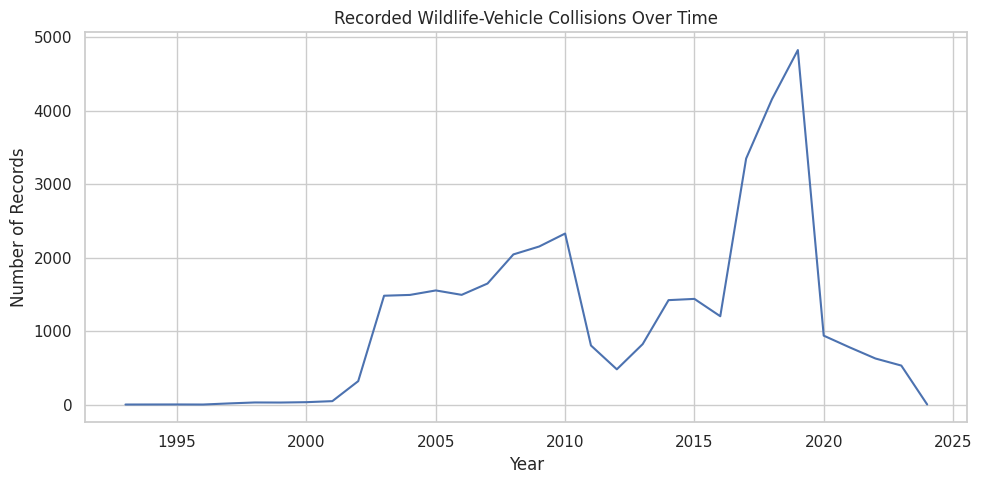

<Axes: xlabel='month'>

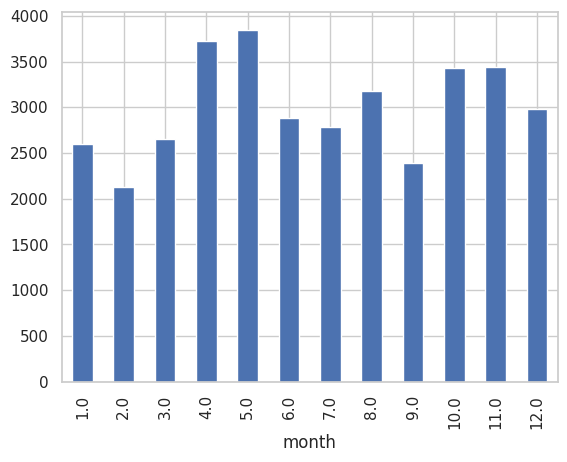

In [9]:
# Analysis 5 — When do collisions occur?

[col for col in df.columns if any(
    x in col.lower() for x in ['year', 'month', 'day', 'date']
)]
year_counts = df['year'].value_counts().sort_index()

year_counts.plot(figsize=(10,5))

plt.title("Recorded Wildlife-Vehicle Collisions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()
df['month'].value_counts().sort_index().plot(kind='bar')

IUCN CONSERVATION STATUS DISTRIBUTION
iucnstatus
LC    35710
NT      208
VU       75
EN       34
NE        3
DD        3
Name: count, dtype: int64

IUCN STATUS PERCENTAGES
iucnstatus
LC    99.10
NT     0.58
VU     0.21
EN     0.09
NE     0.01
DD     0.01
Name: proportion, dtype: float64


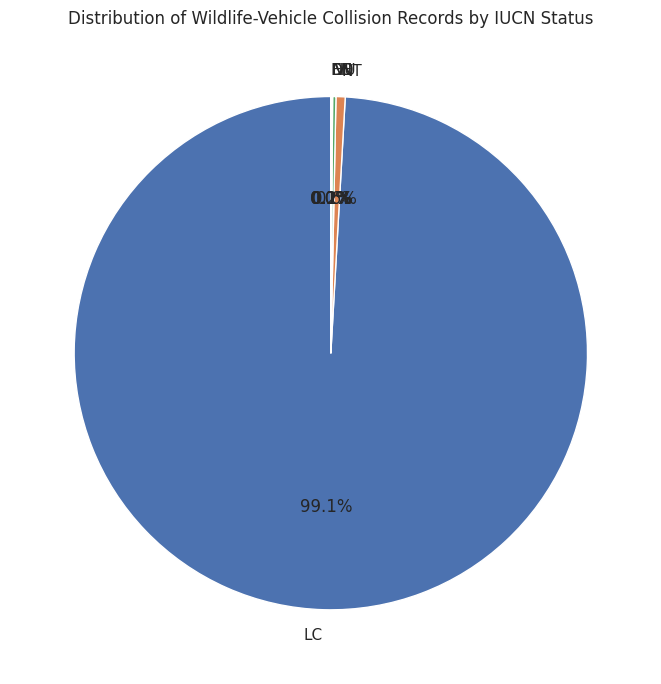

In [10]:
# ANALYSIS 6 — CONSERVATION STATUS (IUCN)

import matplotlib.pyplot as plt
# Find IUCN column
iucn_col = next(
    (col for col in df.columns if 'iucn' in col.lower()),
    None
)

if iucn_col is None:
    print("ERROR: IUCN status column not found.")

else:
    # Count IUCN categories
    iucn_counts = df[iucn_col].value_counts()

    print("IUCN CONSERVATION STATUS DISTRIBUTION")
    print("=" * 50)
    print(iucn_counts)

    # Calculate percentages
    iucn_percentages = (
        df[iucn_col]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nIUCN STATUS PERCENTAGES")
    print("=" * 50)
    print(iucn_percentages)

    # Pie chart
    plt.figure(figsize=(9, 7))

    plt.pie(
        iucn_counts,
        labels=iucn_counts.index,
        autopct='%1.1f%%',
        startangle=90
    )

    plt.title(
        "Distribution of Wildlife-Vehicle Collision Records by IUCN Status"
    )

    plt.tight_layout()
    plt.show()

PEAK COLLISION MONTH FOR EACH SPECIES
                     Peak Month  Collision Records
scientificname                                    
Capreolus capreolus         5.0               3105
Anaxyrus americanus         8.0                264
Bufo spinosus               4.0                237
Bombina bombina             4.0                223
Ambystoma maculatum         4.0                184
Bufo bufo                   4.0                171
Bufo gargarizans            6.0                146
Caiman yacare               2.0                139
Boa imperator               3.0                 81
Athene noctua               8.0                 67
Atelerix algirus            8.0                 42
Athene cunicularia          1.0                 39
Canis latrans              11.0                 31
Boa constrictor             2.0                 28
Calotes versicolor          4.0                 21


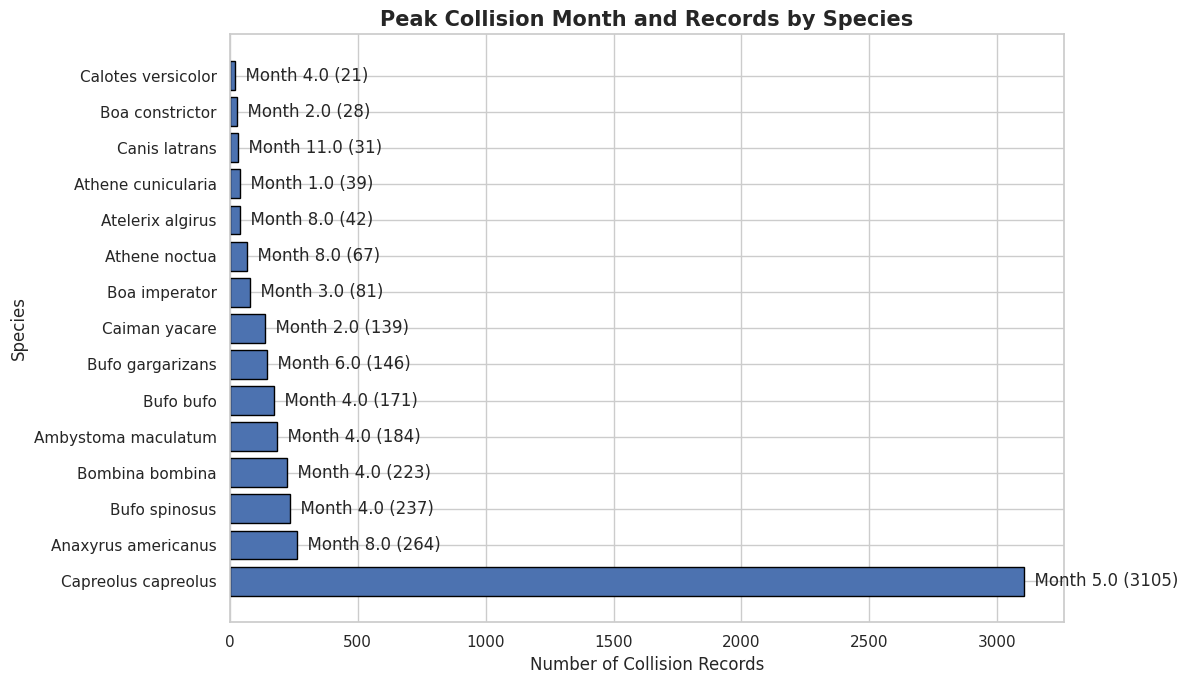

In [11]:
# ANALYSIS 7 — PEAK COLLISION MONTH BY SPECIES

import matplotlib.pyplot as plt
# Select top 15 species
top_species = df['scientificname'].value_counts().head(15).index

# Filter data for top 15 species
species_month_df = df[df['scientificname'].isin(top_species)]

# Create species × month table
species_month_table = pd.crosstab(
    species_month_df['scientificname'],
    species_month_df['month']
)

# Find peak month and number of collisions
peak_month = species_month_table.idxmax(axis=1)
peak_count = species_month_table.max(axis=1)

# Create result table
peak_species_month = pd.DataFrame({
    'Peak Month': peak_month,
    'Collision Records': peak_count
})

# Sort by highest collision count
peak_species_month = peak_species_month.sort_values(
    'Collision Records',
    ascending=False
)

# Display results
print("PEAK COLLISION MONTH FOR EACH SPECIES")
print("=" * 60)
print(peak_species_month)

# GRAPH — PEAK COLLISION MONTH BY SPECIES

plt.figure(figsize=(12, 7))

bars = plt.barh(
    peak_species_month.index,
    peak_species_month['Collision Records'],
    edgecolor='black'
)

plt.title(
    "Peak Collision Month and Records by Species",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Number of Collision Records")
plt.ylabel("Species")

# Display peak month and collision count on each bar
for bar, month, count in zip(
    bars,
    peak_species_month['Peak Month'],
    peak_species_month['Collision Records']
):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  Month {month} ({count})",
        va='center'
    )

plt.tight_layout()
plt.show()

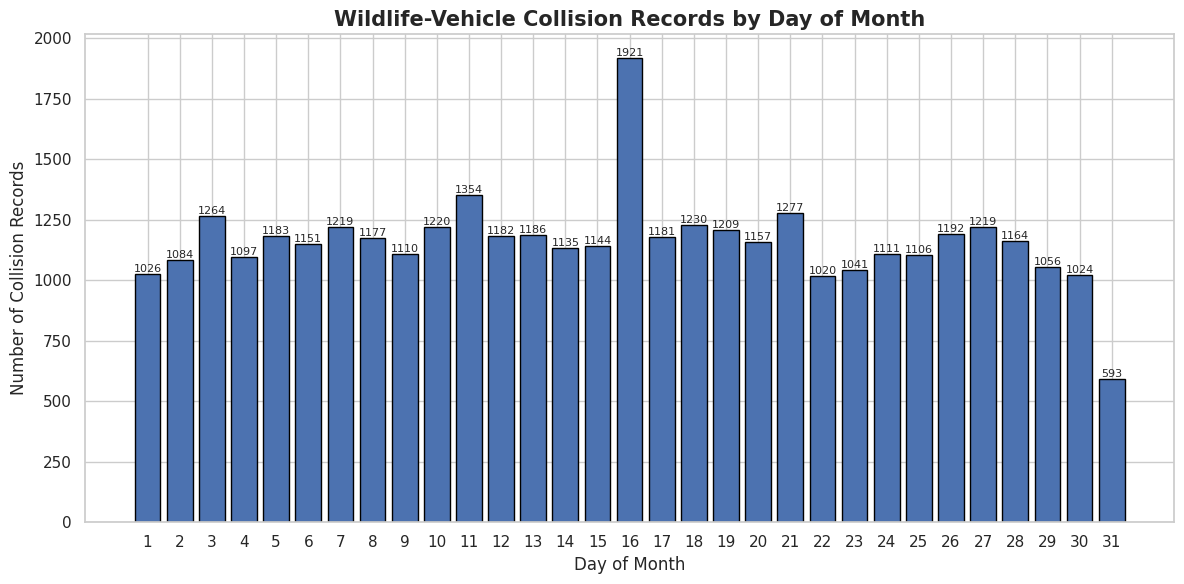

In [12]:
# ANALYSIS 8 — COLLISION RECORDS BY DAY OF MONTH

import matplotlib.pyplot as plt

# Get day of month values
day_values = pd.to_numeric(df['day'], errors='coerce')

# Count collision records for each day
day_counts = day_values.value_counts().sort_index()

# Create graph
plt.figure(figsize=(12, 6))

bars = plt.bar(
    day_counts.index,
    day_counts.values,
    edgecolor='black'
)

plt.title(
    "Wildlife-Vehicle Collision Records by Day of Month",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Day of Month")
plt.ylabel("Number of Collision Records")

plt.xticks(range(1, 32))

# Add values above bars
for bar, value in zip(bars, day_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(int(value)),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()